In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from config import DATA_RAW, DATA_PROCESSED, ROLLING_WINDOWS, LAG_WINDOWS, ZSCORE_THRESHOLD

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(DATA_RAW / "cloud_metrics_historical.csv", parse_dates=["timestamp"])
df = df.sort_values(["timestamp", "resource_id"]).reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded: (21600, 17)
Columns: ['timestamp', 'resource_id', 'resource_type', 'hour', 'day_of_week', 'is_weekend', 'is_month_end', 'cpu_utilization', 'memory_utilization', 'network_in_mbps', 'network_out_mbps', 'disk_io_mbps', 'request_count', 'error_rate_pct', 'cost_per_hour', 'is_anomaly', 'anomaly_type']


## Why feature engineering matters here

Raw metrics like `cpu_utilization=78` mean nothing in isolation.
Is 78% high for this resource? At this hour? Compared to yesterday?

Feature engineering adds **context** — transforming raw numbers into
signals the model can actually reason about:

- **Rolling stats** → what's normal for this resource over time
- **Lag features** → was the previous reading already elevated?
- **Derived ratios** → is CPU and memory both high simultaneously?
- **Temporal features** → is this business hours or 3AM?

This is what separates a 70% F1 model from a 92% F1 model.

In [2]:
# Rolling stats computed per resource (groupby resource_id)
# Windows: 6hr, 12hr, 24hr

metric_cols = ['cpu_utilization', 'memory_utilization',
               'network_in_mbps', 'network_out_mbps',
               'disk_io_mbps', 'cost_per_hour']

print("Computing rolling features...")

for window in ROLLING_WINDOWS:
    for col in metric_cols:
        grp = df.groupby('resource_id')[col]

        df[f'{col}_roll_mean_{window}h'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'{col}_roll_std_{window}h'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )

    # Rolling max for cpu and network specifically
    df[f'cpu_roll_max_{window}h'] = df.groupby('resource_id')['cpu_utilization'].transform(
        lambda x: x.rolling(window, min_periods=1).max()
    )
    df[f'net_in_roll_max_{window}h'] = df.groupby('resource_id')['network_in_mbps'].transform(
        lambda x: x.rolling(window, min_periods=1).max()
    )

print(f"Rolling features added. Shape: {df.shape}")

Computing rolling features...
Rolling features added. Shape: (21600, 59)


In [3]:
print("Computing lag features...")

lag_cols = ['cpu_utilization', 'memory_utilization',
            'network_in_mbps', 'cost_per_hour', 'error_rate_pct']

for lag in LAG_WINDOWS:
    for col in lag_cols:
        df[f'{col}_lag_{lag}h'] = df.groupby('resource_id')[col].transform(
            lambda x: x.shift(lag)
        )

# Fill NaN lags (first few rows per resource) with column mean
lag_feature_cols = [c for c in df.columns if '_lag_' in c]
df[lag_feature_cols] = df[lag_feature_cols].fillna(df[lag_feature_cols].mean())

print(f"Lag features added. Shape: {df.shape}")
print(f"Lag columns created: {lag_feature_cols}")

Computing lag features...
Lag features added. Shape: (21600, 74)
Lag columns created: ['cpu_utilization_lag_1h', 'memory_utilization_lag_1h', 'network_in_mbps_lag_1h', 'cost_per_hour_lag_1h', 'error_rate_pct_lag_1h', 'cpu_utilization_lag_6h', 'memory_utilization_lag_6h', 'network_in_mbps_lag_6h', 'cost_per_hour_lag_6h', 'error_rate_pct_lag_6h', 'cpu_utilization_lag_24h', 'memory_utilization_lag_24h', 'network_in_mbps_lag_24h', 'cost_per_hour_lag_24h', 'error_rate_pct_lag_24h']


In [4]:
print("Computing derived ratio features...")

# CPU to memory ratio — both high simultaneously = strong anomaly signal
df['cpu_mem_ratio'] = df['cpu_utilization'] / (df['memory_utilization'] + 1e-6)

# Network in vs out ratio — imbalance can signal attack or data exfiltration
df['net_in_out_ratio'] = df['network_in_mbps'] / (df['network_out_mbps'] + 1e-6)

# Cost per compute unit — efficiency signal
df['cost_per_cpu'] = df['cost_per_hour'] / (df['cpu_utilization'] + 1e-6)
df['cost_per_request'] = df['cost_per_hour'] / (df['request_count'] + 1)

# Total network pressure
df['total_network_mbps'] = df['network_in_mbps'] + df['network_out_mbps']

# Error pressure — error rate × request count = total errors
df['total_errors'] = (df['error_rate_pct'] / 100) * df['request_count']

# Resource pressure score — combined cpu + memory load
df['resource_pressure'] = (df['cpu_utilization'] + df['memory_utilization']) / 2

# Deviation from rolling mean (Z-score style — per resource)
for col in ['cpu_utilization', 'memory_utilization', 'network_in_mbps', 'cost_per_hour']:
    mean_col = f'{col}_roll_mean_24h'
    std_col  = f'{col}_roll_std_24h'
    df[f'{col}_zscore'] = (df[col] - df[mean_col]) / (df[std_col] + 1e-6)

print(f"Ratio + derived features added. Shape: {df.shape}")

Computing derived ratio features...
Ratio + derived features added. Shape: (21600, 85)


In [5]:
print("Computing temporal features...")

# Already have: hour, day_of_week, is_weekend, is_month_end
# Add more granular temporal context:

# Business hours flag (9AM - 6PM weekdays)
df['is_business_hours'] = (
    (df['hour'] >= 9) & (df['hour'] <= 18) & (df['is_weekend'] == 0)
).astype(int)

# Night hours flag (11PM - 6AM) — anomalies here are more suspicious
df['is_night'] = ((df['hour'] >= 23) | (df['hour'] <= 6)).astype(int)

# Peak hours (11AM - 2PM) — lunch traffic peak
df['is_peak_hours'] = (
    (df['hour'] >= 11) & (df['hour'] <= 14) & (df['is_weekend'] == 0)
).astype(int)

# Cyclical encoding of hour — so model knows hour 23 and hour 0 are adjacent
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclical encoding of day of week
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print(f"Temporal features added. Shape: {df.shape}")

Computing temporal features...
Temporal features added. Shape: (21600, 92)


In [6]:
print("Encoding categorical columns...")

# resource_type → one-hot encode
df = pd.get_dummies(df, columns=['resource_type'], prefix='rtype', drop_first=False)

# resource_id → label encode (ordinal — model uses it as an ID signal)
resource_ids = df['resource_id'].unique()
resource_id_map = {rid: i for i, rid in enumerate(sorted(resource_ids))}
df['resource_id_enc'] = df['resource_id'].map(resource_id_map)

print(f"Encoding done. Shape: {df.shape}")
print(f"Resource ID map: {resource_id_map}")

Encoding categorical columns...
Encoding done. Shape: (21600, 99)
Resource ID map: {'ec2-ml-01': 0, 'ec2-web-01': 1, 'ec2-web-02': 2, 'eks-cluster-01': 3, 'elasticache-01': 4, 'lambda-auth': 5, 'lambda-notify': 6, 'rds-primary': 7, 'rds-replica': 8, 's3-data-lake': 9}


In [7]:
# Separate features into groups for clarity
original_cols = ['cpu_utilization', 'memory_utilization', 'network_in_mbps',
                 'network_out_mbps', 'disk_io_mbps', 'request_count',
                 'error_rate_pct', 'cost_per_hour']

rolling_cols  = [c for c in df.columns if 'roll_' in c]
lag_cols_list = [c for c in df.columns if '_lag_' in c]
ratio_cols    = ['cpu_mem_ratio', 'net_in_out_ratio', 'cost_per_cpu',
                 'cost_per_request', 'total_network_mbps', 'total_errors',
                 'resource_pressure']
zscore_cols   = [c for c in df.columns if '_zscore' in c]
temporal_cols = ['hour', 'day_of_week', 'is_weekend', 'is_month_end',
                 'is_business_hours', 'is_night', 'is_peak_hours',
                 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
encoded_cols  = [c for c in df.columns if c.startswith('rtype_')] + ['resource_id_enc']

print("=" * 50)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 50)
print(f"Original metrics      : {len(original_cols)}")
print(f"Rolling stats         : {len(rolling_cols)}")
print(f"Lag features          : {len(lag_cols_list)}")
print(f"Ratio / derived       : {len(ratio_cols)}")
print(f"Z-score deviations    : {len(zscore_cols)}")
print(f"Temporal              : {len(temporal_cols)}")
print(f"Encoded categoricals  : {len(encoded_cols)}")
print(f"─────────────────────────────────────")
total_features = len(original_cols + rolling_cols + lag_cols_list +
                     ratio_cols + zscore_cols + temporal_cols + encoded_cols)
print(f"Total feature count   : {total_features}")
print(f"Total columns in df   : {df.shape[1]}")

FEATURE ENGINEERING SUMMARY
Original metrics      : 8
Rolling stats         : 42
Lag features          : 15
Ratio / derived       : 7
Z-score deviations    : 4
Temporal              : 11
Encoded categoricals  : 8
─────────────────────────────────────
Total feature count   : 95
Total columns in df   : 99


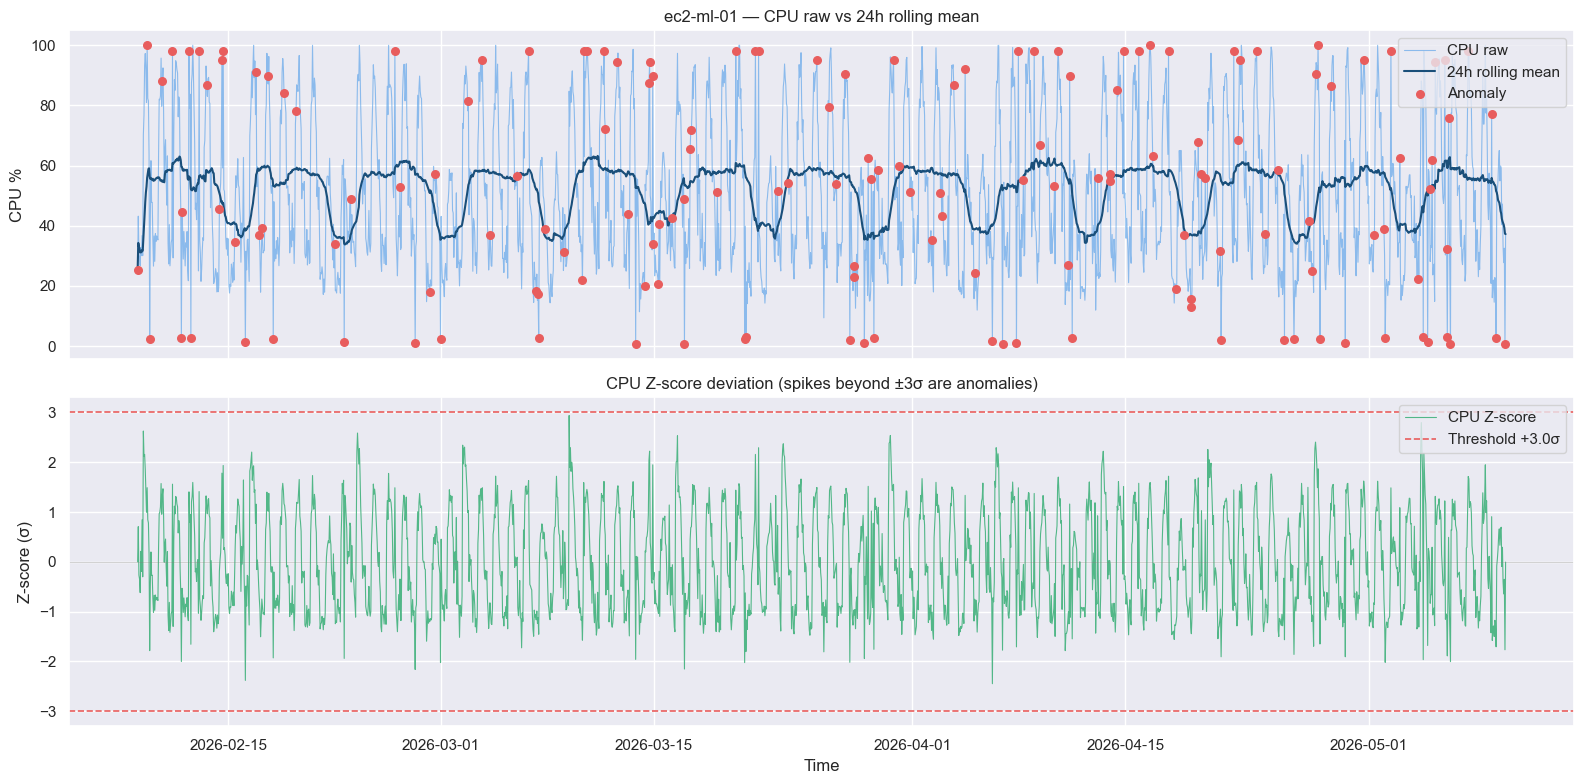

In [8]:
res = df[df['resource_id'] == 'ec2-ml-01'].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# CPU raw vs rolling mean
axes[0].plot(res['timestamp'], res['cpu_utilization'],
             alpha=0.6, color='#4C9BE8', linewidth=0.8, label='CPU raw')
axes[0].plot(res['timestamp'], res['cpu_utilization_roll_mean_24h'],
             color='#1A4F7A', linewidth=1.5, label='24h rolling mean')
anomalies = res[res['is_anomaly'] == 1]
axes[0].scatter(anomalies['timestamp'], anomalies['cpu_utilization'],
                color='#E85D5D', s=30, zorder=5, label='Anomaly')
axes[0].set_title('ec2-ml-01 — CPU raw vs 24h rolling mean')
axes[0].set_ylabel('CPU %')
axes[0].legend(loc='upper right')

# Z-score deviation
axes[1].plot(res['timestamp'], res['cpu_utilization_zscore'],
             color='#52B788', linewidth=0.8, label='CPU Z-score')
axes[1].axhline(y=ZSCORE_THRESHOLD,  color='#E85D5D', linestyle='--',
                linewidth=1.2, label=f'Threshold +{ZSCORE_THRESHOLD}σ')
axes[1].axhline(y=-ZSCORE_THRESHOLD, color='#E85D5D', linestyle='--', linewidth=1.2)
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
axes[1].set_title('CPU Z-score deviation (spikes beyond ±3σ are anomalies)')
axes[1].set_ylabel('Z-score (σ)')
axes[1].set_xlabel('Time')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

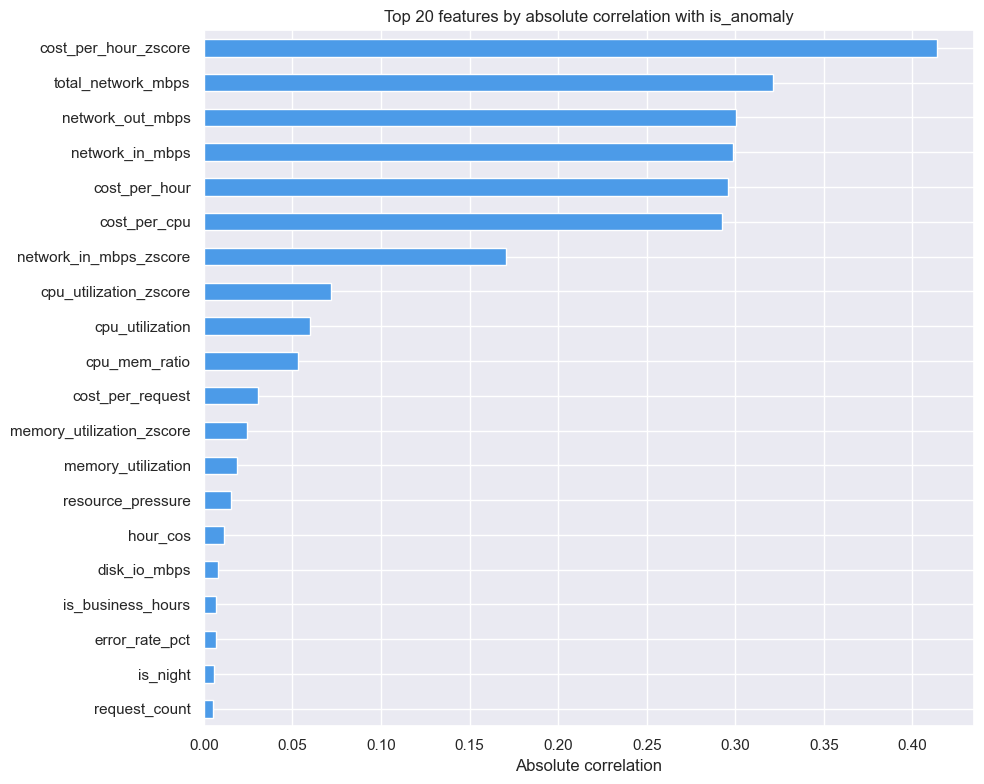


Top 10 features correlated with anomaly:
cost_per_hour_zscore      0.4140
total_network_mbps        0.3214
network_out_mbps          0.3002
network_in_mbps           0.2988
cost_per_hour             0.2961
cost_per_cpu              0.2924
network_in_mbps_zscore    0.1707
cpu_utilization_zscore    0.0720
cpu_utilization           0.0597
cpu_mem_ratio             0.0531
Name: is_anomaly, dtype: float64


In [9]:
feature_cols_for_corr = (original_cols + ratio_cols + zscore_cols +
                         ['is_business_hours', 'is_night', 'hour_sin', 'hour_cos'])

corr_with_target = df[feature_cols_for_corr + ['is_anomaly']]\
    .corr()['is_anomaly']\
    .drop('is_anomaly')\
    .abs()\
    .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.head(20).plot(kind='barh', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 20 features by absolute correlation with is_anomaly')
ax.set_xlabel('Absolute correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features correlated with anomaly:")
print(corr_with_target.head(10).round(4))

In [10]:
# Drop columns not needed for modelling
drop_cols = ['anomaly_type', 'timestamp', 'resource_id']
df_model = df.drop(columns=drop_cols)

# Verify no nulls remain
null_check = df_model.isnull().sum()
if null_check.sum() == 0:
    print("No null values — clean!")
else:
    print("Nulls found:")
    print(null_check[null_check > 0])
    df_model = df_model.fillna(df_model.mean(numeric_only=True))
    print("Filled with column means.")

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
out_path = DATA_PROCESSED / "cloud_metrics_featured.csv"
df_model.to_csv(out_path, index=False)

print(f"\nSaved to: {out_path}")
print(f"Final shape: {df_model.shape}")
print(f"Target distribution:\n{df_model['is_anomaly'].value_counts()}")

No null values — clean!

Saved to: D:\B.TECH\Projects\cloud-anomaly-detector\data\processed\cloud_metrics_featured.csv
Final shape: (21600, 96)
Target distribution:
is_anomaly
0    20089
1     1511
Name: count, dtype: int64
